<a href="https://colab.research.google.com/github/DinaMMahfouz/machine_learning/blob/main/PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import numpy as np

# **Intoduction: Differences between array, numpy array and tensors**

In [6]:
my_list=[1,2,3,4]
my_list

[1, 2, 3, 4]

In [12]:
np1=np.random.rand(3,4)
print(np1)
np1.dtype

[[0.50278544 0.78720013 0.23852167 0.4258851 ]
 [0.72831364 0.72734998 0.78110886 0.72410652]
 [0.7881831  0.82690748 0.52095783 0.97336798]]


dtype('float64')

In [11]:
tensor_2d=torch.randn(3,4)
print(tensor_2d)
tensor_2d.dtype

tensor([[ 0.1102,  0.0440,  0.1887,  0.0157],
        [ 0.4337,  0.0979, -0.7349, -1.4387],
        [-0.3103,  0.6005, -0.5554, -0.2828]])


torch.float32

In [13]:
tensor_3d=torch.zeros(2,3,4)
tensor_3d

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

In [17]:
#Create tensor out of numpy array
my_tensor=torch.tensor(np1)
my_tensor

tensor([[0.5028, 0.7872, 0.2385, 0.4259],
        [0.7283, 0.7273, 0.7811, 0.7241],
        [0.7882, 0.8269, 0.5210, 0.9734]], dtype=torch.float64)

# **Tensor Operations**

In [18]:
my_torch=torch.arange(10)
my_torch

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [19]:
#Reshape and View
my_torch=my_torch.reshape(2,5)
my_torch

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [23]:
#Reshape if we don't know the number of items using -1
mytorch2=my_torch.reshape(2,-1)
mytorch2

#or

mytorch3=my_torch.reshape(-1,5)
mytorch3

#or
mytorch3=my_torch.view(2,5)
mytorch3

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [32]:
# With reshape and view, they will update

mytorch5=torch.arange(10)
mytorch5

mytorch6=mytorch5.reshape(2,5)
mytorch6

mytorch5[1]=1212
mytorch5

mytorch6

tensor([[   0, 1212,    2,    3,    4],
        [   5,    6,    7,    8,    9]])

In [33]:
#Slices
mytorch7=torch.arange(10)
mytorch7

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [34]:
#Grab a specific item
mytorch7[7]

tensor(7)

In [36]:
mytorch8=mytorch7.reshape(2,5)
mytorch8

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [37]:
mytorch8[:,1]

tensor([1, 6])

In [38]:
#Return Column
mytorch8[:,1:]


tensor([[1, 2, 3, 4],
        [6, 7, 8, 9]])

# **Tensor Math Operations**

In [40]:
tensor_a=torch.tensor([1,2,3,4,5])
tensor_b=torch.tensor([5,6,7,8,9])

In [41]:
#Addition
tensor_a+tensor_b

tensor([ 6,  8, 10, 12, 14])

In [53]:
#Addition Longhand
torch.add(tensor_a,tensor_b)

tensor_a.add(tensor_b)

tensor([ 6,  8, 10, 12, 14])

In [44]:
#Subtraction
tensor_a-tensor_b

tensor([-4, -4, -4, -4, -4])

In [45]:
#Subtraction Longhand
torch.sub(tensor_a,tensor_b)

tensor([-4, -4, -4, -4, -4])

In [47]:
#Multiply
tensor_a*tensor_b
torch.mul(tensor_a,tensor_b)

tensor([ 5, 12, 21, 32, 45])

In [48]:
#Divide
tensor_a/tensor_b
torch.div(tensor_a,tensor_b)

tensor([0.2000, 0.3333, 0.4286, 0.5000, 0.5556])

In [50]:
#Modulus
tensor_a%tensor_b
torch.remainder(tensor_a,tensor_b)

tensor([1, 2, 3, 4, 5])

In [51]:
#Exponents
tensor_a**tensor_b
torch.pow(tensor_a,tensor_b)

tensor([      1,      64,    2187,   65536, 1953125])

In [55]:
tensor_a=tensor_a+tensor_b
#or
tensor_a.add_(tensor_b)

tensor([16, 20, 24, 28, 32])

# **Simple Neural Network**

In [31]:
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F


In [32]:
#Create a Model Class that inherits nn.Module

class Model(nn.Module):
  #Input Layer (4 features of Flower)
  # -> Hidden Layer 1 (Number of Neuorns)
  # -> H2 (n)
  # -> Output(3 Classes of Isris Flower)
 def __init__(self,in_features=4,h1=8,h2=8,out_features=3):
  super().__init__()
  #Create Layers
  self.fc1=nn.Linear(in_features,h1)
  self.fc2=nn.Linear(h1,h2)
  self.out=nn.Linear(h2,out_features)
 def forward(self,x):
    x=F.relu(self.fc1(x))
    x=F.relu(self.fc2(x))
    x=self.out(x)
    return x

In [33]:
#Pick a manual seed for randomization
torch.manual_seed(32)
#Creat and instance of model
model=Model()
print(model)

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=3, bias=True)
)


In [34]:
import matplotlib.pyplot as plt
%matplotlib inline

In [35]:
df=pd.read_csv("iris.csv")

In [36]:
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [37]:
#Change from categorical to numerical
df['variety']=df['variety'].replace({'Setosa':0.0,'Versicolor':1.0,'Virginica':2.0})

/tmp/ipykernel_28800/793858725.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['variety']=df['variety'].replace({'Setosa':0.0,'Versicolor':1.0,'Virginica':2.0})


In [38]:
#Train Test Split! Set X, y
X=df.drop('variety',axis=1).values
y=df['variety'].values

In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=32)

In [40]:
#Convert X to tensors float
X_train=torch.FloatTensor(X_train)
X_test=torch.FloatTensor(X_test)

In [41]:
#Convert y to tensors long
y_train=torch.LongTensor(y_train)
y_test=torch.LongTensor(y_test)

In [42]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

# **Train The Model**

In [43]:
epochs=100
losses=[]
for i in range(epochs):
  y_pred=model.forward(X_train)#take the details to go foward and predict
  loss=criterion(y_pred,y_train) #Messaure the loss
  #Keep Track of out losses
  losses.append(loss.detach().item())#print every 10 epoch
  if i%10==0:
    print(f'Epoch: {i} Loss: {loss}')
  #Do some back propagation, take error and feed it back to learn better
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch: 0 Loss: 1.0631177425384521
Epoch: 10 Loss: 0.8529143929481506
Epoch: 20 Loss: 0.7415196299552917
Epoch: 30 Loss: 0.6668493151664734
Epoch: 40 Loss: 0.5850216150283813
Epoch: 50 Loss: 0.46107885241508484
Epoch: 60 Loss: 0.2674432098865509
Epoch: 70 Loss: 0.1358489990234375
Epoch: 80 Loss: 0.09010109305381775
Epoch: 90 Loss: 0.07374869287014008


Text(0.5, 0, 'Epochs')

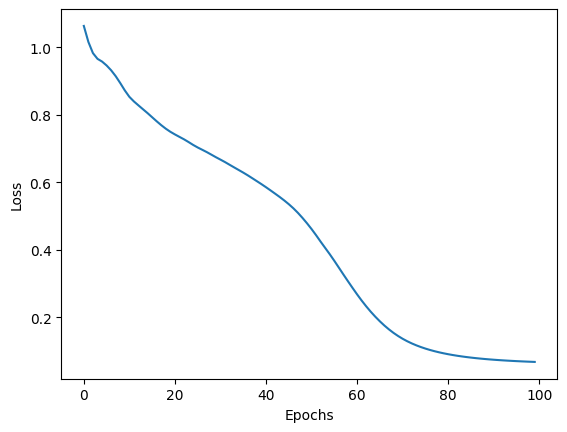

In [44]:
plt.plot(range(epochs),losses)
plt.ylabel('Loss')
plt.xlabel('Epochs')

# **Evaluate Using Test Set**

In [45]:
with torch.no_grad(): #turn of back propgation
 y_eval=model.forward(X_test)
 loss=criterion(y_eval,y_test)
 print(loss)

tensor(0.0495)


In [46]:
correct=0
with torch.no_grad():
  for i,data in enumerate(X_test):
    y_val=model.forward(data)
    print(f'{i+1:2}. {str(y_val):38} {y_test[i]} \t {y_val.argmax().item()}')

    #Correct or not
    if y_val.argmax().item()==y_test[i]:
      correct+=1
print(f'{correct} out of {len(y_test)} = {100*correct/len(y_test):.2f}%')


 1. tensor([-4.9732,  5.0125,  1.6831])    1 	 1
 2. tensor([ 4.7830, -3.7286, -2.9560])    0 	 0
 3. tensor([ 3.9088, -2.7546, -2.6659])    0 	 0
 4. tensor([-5.1643,  5.4570,  1.4120])    1 	 1
 5. tensor([-7.8695,  3.9144,  6.7425])    2 	 2
 6. tensor([-8.6391,  5.3856,  6.0880])    2 	 2
 7. tensor([ 3.3893, -2.1626, -2.5284])    0 	 0
 8. tensor([ 3.9409, -2.7814, -2.6737])    0 	 0
 9. tensor([-4.5980,  5.3799,  0.7242])    1 	 1
10. tensor([ 4.5122, -3.4276, -2.8623])    0 	 0
11. tensor([-5.7149,  5.9326,  1.7038])    1 	 1
12. tensor([-8.4303,  3.2562,  8.0961])    2 	 2
13. tensor([-3.6693,  4.9815,  0.0520])    1 	 1
14. tensor([-3.2535,  5.0415, -0.5296])    1 	 1
15. tensor([-7.7944,  3.9601,  6.5314])    2 	 2
16. tensor([-8.4149,  2.5725,  8.8736])    2 	 2
17. tensor([-5.1371,  4.6423,  2.2665])    1 	 1
18. tensor([-7.2262,  4.1477,  5.6069])    2 	 2
19. tensor([-3.6053,  5.2527, -0.2888])    1 	 1
20. tensor([ 4.8667, -3.7673, -3.0489])    0 	 0
21. tensor([ 4.1671,

# **Feed New Data**

In [48]:
new_iris= torch.tensor([4.7,3.2,1.3,0.2])

In [51]:
with torch.no_grad():
  print(model(new_iris))
  print(model(new_iris).argmax().item())
  if model.forward(new_iris).argmax().item()==0:
    print('Setosa')
  elif model.forward(new_iris).argmax().item()==1:
    print('Versicolor')
  else:
    print('Virginica')

tensor([ 4.3745, -3.3021, -2.7568])
0
Setosa


# **Save our NN Model**

In [52]:
torch.save(model.state_dict(),'iris_model.pt')

In [54]:
#Load Saved Model
new_model=Model()
new_model.load_state_dict(torch.load('iris_model.pt'))

<All keys matched successfully>

In [55]:
#Make sure it loaded correctly
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=3, bias=True)
)